In [3]:
using Plots
using Plots.PlotMeasures
using HDF5

### Initial Parameters ###

In [22]:
N = 61 #Number of lattice sites per dimension
d = 1 #Number of spatial dimensions
Dim = 10 #Truncated local Hilbert space dimension
a = 0.5 #Lattice spacing

n_0 = round(Int, ((N-1)/2)) #Index of the point at the center of the lattice (0-based indexing).

mass = 1.0
m0 = 1.0 #Basis frequency
l = 0.1 #phi^4 coupling strength

r = [1,2,3,4] #[5,10,20]
ti = 0.0
tf = 5.0 #20.0
dt = 0.2
t_range = range(ti, tf, step=dt);

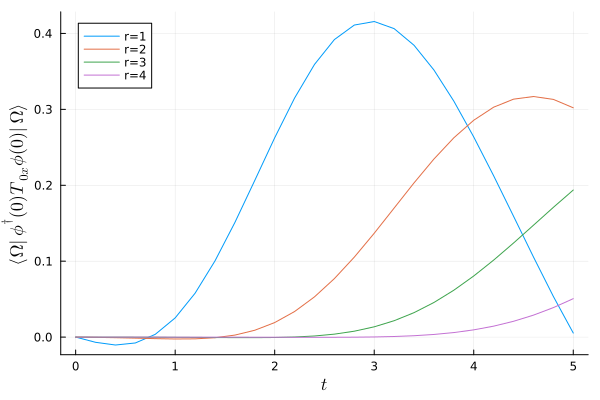

In [23]:
plt = plot(guidefont=font(12),
    xlabel="\$t\$",
    ylabel="\$\\langle\\Omega|\\phi^{\\dagger}(0)T_{0x}\\phi(0)|{\\Omega}\\rangle\$")

for i in 1:length(r)
    data = h5open("Z:/Energy Correlator/1d_EEC_data/EFEV,N=$N,a=$a,l=$l,m=$mass,r=$(r[i]),ti=$ti,tf=$tf,dt=$dt", "r")
    Eflux = data["Eflux"][1:end]
    close(data)
    plot!(t_range, real(Eflux), label="r=$(r[i])")
end

plot!(legend=:topleft)

plt
#savefig("C:/Users/karlo/OneDrive/Documents/Programs/VSC Julia/Energy Correlator/Plots/EFEV, N=$N, m=1, lambda=1e-1, truncated HS dim=$Dim")

Interpretation:
* Above is a plot of energy *flux*, i.e. the *rate* at which a detector measures energy. As such, positive values correspond to incoming energy and negative values to outgoing energy
* Due to finite lattice effects, the excitation (e.g. wave packet) isn't completely localized, so there are additional 'pulses' of energy that hit the detector (as indicated by the secondary peak)

Notes:
* It will be difficult to accurately calculate EECs with long time integration. Maybe it will be possible to calculate EEC matrix elements up to t1=t2=10 with dt=0.5 if we enforce matrix symmetry